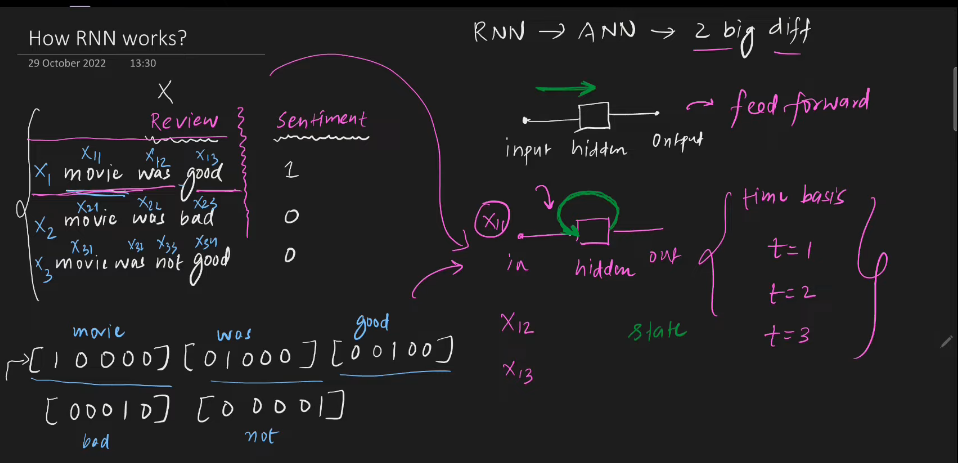

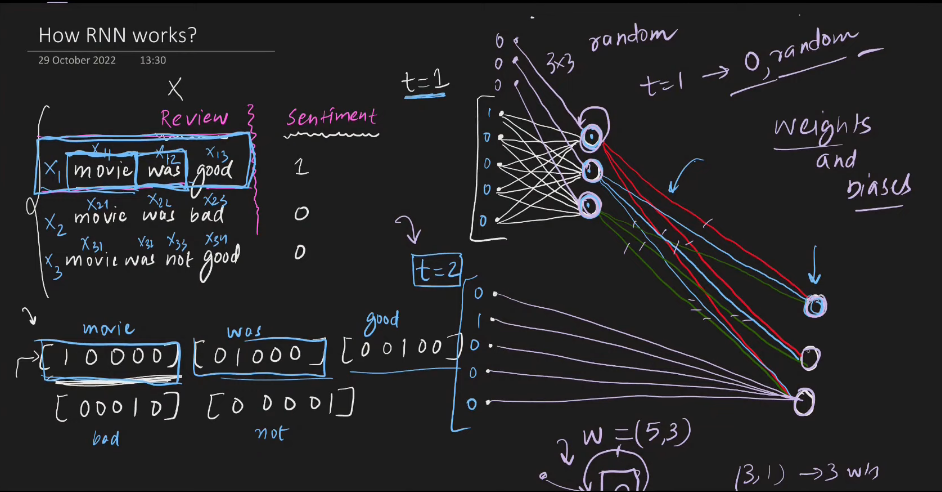


- Focus: Understanding RNNs for sentiment analysis on movie reviews.

---

### 🔹 Input Data Example
Three movie reviews are given with corresponding sentiment labels:
```
x₁: "movie was good" → Sentiment = 1 (positive)
x₂: "movie was bad"   → Sentiment = 0 (negative)
x₃: "movie was not good" → Sentiment = 0 (negative)
```

Each word in the sentence is treated as a time step in a sequence:
- Words: `movie`, `was`, `good`, `bad`, `not`

Words are converted into **one-hot encoded vectors**:
- `movie` → [1, 0, 0, 0]
- `was` → [0, 1, 0, 0]
- `good` → [0, 0, 1, 0]
- `bad` → [0, 0, 0, 1]
- `not` → [0, 0, 0, 1]

> Note: The vocabulary size appears to be 4 or more based on these encodings.

---

### 🔹 Key Concept: Sequential Processing
RNNs process sequences one element at a time, maintaining a **hidden state** that carries information from previous steps.

#### Diagram Explanation:
- A basic RNN unit has:
  - **Input (x_t)**: current word vector
  - **Hidden State (h_t)**: memory of previous inputs
  - **Output (o_t)**: prediction or intermediate result

> The diagram shows:
> ```
> x₁₁ (movie) → input → hidden → output
>         ↓
>     t=1
> ```

Then it moves to `t=2` (next word), reusing the same network structure but updating the hidden state.

This is contrasted with a standard **Feed-Forward ANN**, which processes all inputs simultaneously — not suitable for sequences.

---

### 🔹 Comparison: RNN vs ANN
- **ANN**: All inputs processed at once → no memory of order.
- **RNN**: Processes one input at a time, with **recurrent connections** allowing it to remember past states.

> Written:  
> `RNN → ANN → 2 big diff`  
> Meaning: There’s a significant difference between RNN and ANN in handling sequences.

---

### 🔹 Time Steps Visualization
For the first review: `"movie was good"`

At each time step:
- **t=1**: Input = `movie` → [1,0,0,0]
- **t=2**: Input = `was` → [0,1,0,0]
- **t=3**: Input = `good` → [0,0,1,0]

The RNN updates its **hidden state** at each step using:
```text
h_t = f(W_x * x_t + W_h * h_{t-1} + b)
```
Where:
- `W_x`: weight matrix for input
- `W_h`: weight matrix for hidden state
- `f`: activation function (e.g., tanh or sigmoid)

---

### 🔹 Network Architecture Sketch
On the right side:
- A neural network with:
  - 3 input nodes (possibly representing 3 features or embedded word dimensions)
  - 3 hidden nodes
  - 1 output node
- Weights and biases are shown connecting layers
- At `t=1`, initial hidden state is set to zero or random
- At `t=2`, the hidden state from `t=1` is fed back into the network

> This illustrates **unrolling** the RNN over time.

---

### 🔹 Why RNNs Are Better for Sequences?
Because they maintain **context** across time steps:
- For `"movie was good"`: the model learns positive sentiment by combining words.
- For `"movie was not good"`: the word `"not"` flips the sentiment, and the RNN can learn this dependency through the hidden state.

---

### 🔹 Summary of Key Points
| Feature | ANN | RNN |
|--------|-----|-----|
| Input Handling | All at once | Sequential |
| Memory | No | Yes (via hidden state) |
| Use Case | Static data | Time-series, text, speech |

---

### ✅ Final Takeaway
RNNs are designed for **sequential data** where order matters. They use **recurrence** to pass information from one step to the next, enabling models to understand context and dependencies over time — essential for tasks like sentiment analysis, language modeling, etc.



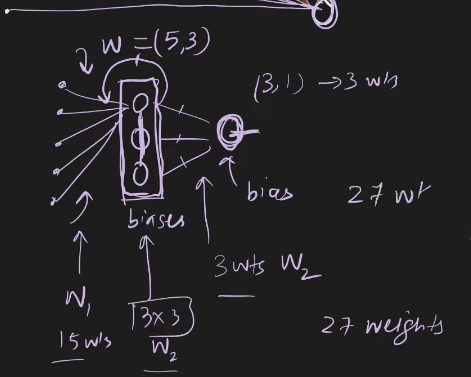



---

### 🔹 Overview
This appears to be a sketch of a **neural network layer**, possibly a hidden layer with 3 neurons (units), showing:
- Input connections
- Weights
- Biases
- Dimensions of weight matrices

Let’s interpret each component:

---

### 🔹 Key Elements in the Diagram

#### 1. **Neuron Structure**
- A vertical rectangle represents a **layer of 3 neurons**.
- Each neuron has:
  - Inputs from previous layer
  - Weighted connections
  - A bias term
  - An output (activation)

#### 2. **Weights (W)**
- **`W₁`**: There are **15 weights** labeled as `W₁`.
  - Likely comes from input dimension × number of neurons.
  - If there are 5 inputs and 3 neurons:  
    → 5 × 3 = **15 weights** ✅
- **`W₂`**: Labeled as **"3×3"**, meaning a **3×3 weight matrix**.
  - This could represent **recurrent weights** (e.g., from hidden state to hidden state in an RNN).
  - So, 3 neurons → 3 neurons: 3×3 = **9 weights**.
  - But it says "3 wts W₂", which might be a typo or shorthand.

> Wait — this seems inconsistent. Let's re-analyze.

Actually, the label **`W₂ = (3,1)` → 3 wts** suggests that:
- The output layer has **3 neurons**, each producing one output.
- So, if we're going from a **hidden layer of size 3 to output layer of size 1**, then:
  - Output weights would be a **(3,1)** matrix → 3 weights.
  - That matches: “(3,1) → 3 wts”

But earlier, `W = (5,3)` is written above the box.

So let’s piece it together.

---

### 🔹 Full Interpretation

#### 🟦 Input Layer → Hidden Layer
- Input vector size: **5 features**
- Hidden layer: **3 neurons**
- Therefore, weight matrix: **5 × 3 = 15 weights** → labeled as `W₁`
- These are the **input-to-hidden weights**

#### 🟨 Hidden Layer → Hidden Layer (Recurrent)
- In an RNN, the hidden state at time `t` depends on previous hidden state.
- So, **hidden-to-hidden weights**: 3 × 3 = **9 weights**
- But this isn't explicitly labeled here.

Wait — instead, the diagram shows:
- `W = (5,3)` → probably refers to **input-to-hidden weights** (`W₁`)
- Then `(3,1) → 3 wts` → likely **hidden-to-output weights** (`W₂`)
- And `3 wts W₂` → so output layer has 3 weights from 3 hidden units to 1 output

So total:
- `W₁`: 5 × 3 = **15 weights**
- `W₂`: 3 × 1 = **3 weights**
- Total weights: **18**

But also:
- There's a note saying "**27 weights**" → where does that come from?

Ah! Look again:
> `27 wt` is written near the bottom right.

Possibly:
- If the **hidden layer has 3 neurons**, and each neuron connects back to itself (recurrence), then:
  - Hidden-to-hidden: 3 × 3 = **9 weights**
- Plus:
  - Input-to-hidden: 5 × 3 = **15 weights**
  - Hidden-to-output: 3 × 1 = **3 weights**
- Total: 9 + 15 + 3 = **27 weights**

✅ That makes sense!

So the **27 weights** include:
| Connection | Matrix Size | # of Weights |
|-----------|-------------|--------------|
| Input → Hidden | 5×3 | 15 |
| Hidden → Hidden (recurrent) | 3×3 | 9 |
| Hidden → Output | 3×1 | 3 |
| **Total** | — | **27** |

---

### 🔹 Biases
- Each neuron has a **bias**.
- There are **3 neurons**, so:
  - 3 biases for hidden layer
  - 1 bias for output layer?
  - But only **"biases"** are shown pointing into the hidden layer

So likely:
- 3 biases for the hidden layer (one per neuron)
- Possibly another bias for output layer, but not shown

---

### 🔹 Summary of Notation

| Label | Meaning |
|------|--------|
| `W = (5,3)` | Input-to-hidden weight matrix (5 inputs, 3 hidden units) |
| `(3,1) → 3 wts` | Hidden-to-output weight matrix (3 hidden units → 1 output) |
| `W₁` | Input-to-hidden weights: 15 total |
| `W₂` | Hidden-to-output weights: 3 total |
| `3×3` | Recurrent weights (hidden-to-hidden): 9 total |
| `27 weights` | Total parameters: 15 + 9 + 3 = 27 |
| `biases` | One bias per neuron in hidden layer → 3 biases |

---

### 🔹 Final Answer: What Is Being Shown?

This diagram illustrates the **parameter count** in a simple RNN-like architecture:

- **Input size**: 5
- **Hidden layer size**: 3
- **Output size**: 1
- **Connections**:
  - Input → Hidden: 5 × 3 = 15 weights
  - Hidden → Hidden (recurrent): 3 × 3 = 9 weights
  - Hidden → Output: 3 × 1 = 3 weights
- **Total weights**: 15 + 9 + 3 = **27**
- **Biases**: At least 3 (one per hidden unit)

> This matches typical RNN structure:
> ```
> h_t = tanh(W_x * x_t + W_h * h_{t-1} + b_h)
> y_t = W_o * h_t + b_o
> ```

Where:
- `W_x`: 5×3
- `W_h`: 3×3
- `W_o`: 3×1
- Total: 15 + 9 + 3 = 27 weights

---

### ✅ Conclusion

This diagram explains how many **weights and biases** are involved in a small RNN model processing sequences with:
- 5-dimensional input
- 3 hidden units
- 1 output

And concludes that the total number of **trainable parameters** is **27** (including recurrent connections).



In [1]:
from keras import Sequential
from keras.layers import Dense,SimpleRNN

In [2]:
model = Sequential()
model.add(SimpleRNN(3,input_shape=(4,5)))
model.add(Dense(1,activation  = 'sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
print(model.get_weights()[0].shape)
model.get_weights()[0]

(5, 3)


array([[-0.02901554,  0.8390246 ,  0.4151302 ],
       [-0.01285046, -0.05884993, -0.32988757],
       [-0.8238668 , -0.52738506,  0.86295074],
       [-0.23803109,  0.6046657 ,  0.24922734],
       [ 0.45481926,  0.4090901 ,  0.748807  ]], dtype=float32)

In [10]:
print(model.get_weights()[1].shape) #feedback connections
model.get_weights()[1]

(3, 3)


array([[-0.588007  ,  0.31955504,  0.7430562 ],
       [-0.78793055, -0.01868884, -0.6154804 ],
       [-0.18279304, -0.94738334,  0.2627764 ]], dtype=float32)

In [11]:
print(model.get_weights()[2].shape)
model.get_weights()[2]

(3,)


array([0., 0., 0.], dtype=float32)

In [12]:
print(model.get_weights()[3].shape)
model.get_weights()[3]

(3, 1)


array([[-0.0876683 ],
       [-0.31913126],
       [-0.27308255]], dtype=float32)

In [13]:
print(model.get_weights()[4].shape)
model.get_weights()[4]

(1,)


array([0.], dtype=float32)

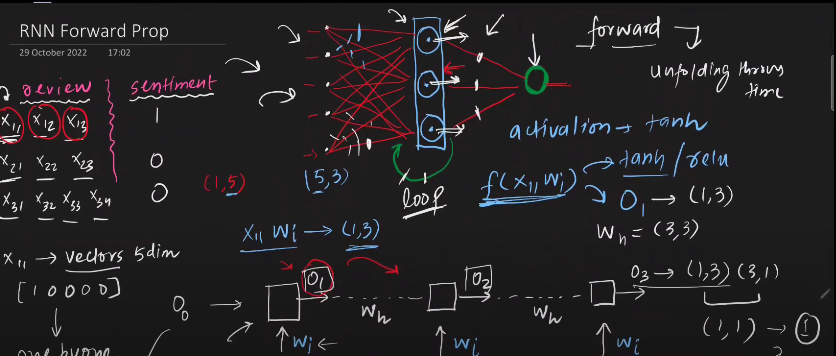

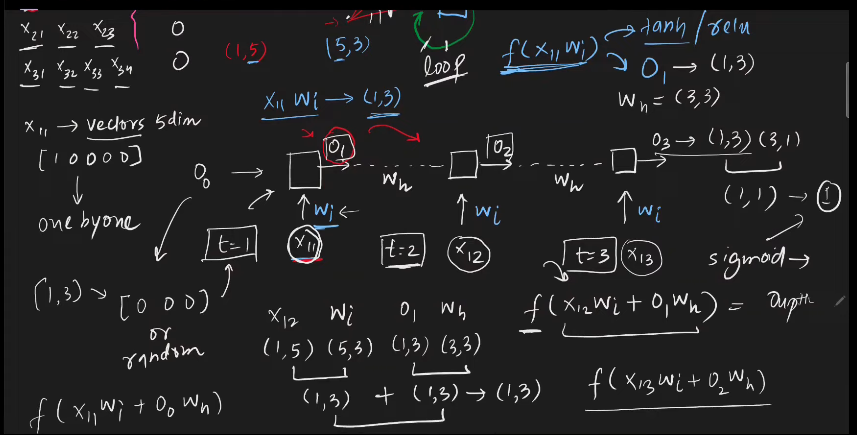


---

## 🧠 Overview: How RNN Forward Propagation Works

The core idea is:
> An RNN processes input **sequentially**, one timestep at a time, using **recurrent connections** to maintain memory via a **hidden state**.

This allows it to model sequences like text, speech, or time series.

---

### 🔹 Key Concepts from the Diagrams

#### 1. **Input Representation**
- Each word is converted into a **one-hot vector**.
- Example: `"movie"` → `[1,0,0,0,0]` (5-dimensional)
- So each `x_t` (input at time t) is a **(1,5)** vector.

> `x₁₁`, `x₁₂`, `x₁₃` → words in sentence 1: "movie was good"

So:
- `x₁₁`: "movie" → [1,0,0,0,0]
- `x₁₂`: "was" → [0,1,0,0,0]
- `x₁₃`: "good" → [0,0,1,0,0]

Each word is processed **one by one** → **time steps t=1, t=2, t=3**

---

### 🔹 Architecture of the RNN Unit

At each time step `t`, the RNN computes:

```
h_t = f(W_i * x_t + W_h * h_{t-1} + b)
```

Where:
- `x_t`: input at time t → shape `(1,5)`
- `h_{t-1}`: previous hidden state → shape `(1,3)`
- `W_i`: input-to-hidden weight matrix → `(5,3)` → maps 5D input to 3D hidden
- `W_h`: hidden-to-hidden weight matrix → `(3,3)` → recurrent connection
- `f`: activation function (e.g., `tanh` or `ReLU`)
- `b`: bias

Then output:
```
o_t = g(W_o * h_t + b_o)
```
- `g`: usually sigmoid or softmax for classification
- Output `o_t` → shape `(1,1)` or `(1,3)` depending on task

---

### 🔹 Step-by-Step Forward Pass

Let’s walk through the sequence: `"movie was good"`

#### ✅ Time Step t=1: Process "movie"
- Input: `x₁₁` → `(1,5)` → `[1,0,0,0,0]`
- Initial hidden state: `h₀ = 0` (zero vector)
- Compute:
  ```
  h₁ = tanh(W_i * x₁₁ + W_h * h₀ + b)
       = tanh(W_i * x₁₁ + 0)
       = tanh((5,3) × (1,5)^T) → (1,3)
  ```
- So `h₁` is a `(1,3)` vector → hidden state after first word

#### ✅ Time Step t=2: Process "was"
- Input: `x₁₂` → `(1,5)`
- Use previous hidden state: `h₁`
- Compute:
  ```
  h₂ = tanh(W_i * x₁₂ + W_h * h₁ + b)
  ```
- Now both input and past memory contribute

#### ✅ Time Step t=3: Process "good"
- Input: `x₁₃` → `(1,5)`
- Hidden state: `h₂`
- Compute:
  ```
  h₃ = tanh(W_i * x₁₃ + W_h * h₂ + b)
  ```

Finally, compute output:
```
o₃ = sigmoid(W_o * h₃ + b_o)
```
→ Predict sentiment (e.g., 1 = positive)

---

### 🔹 Visual Breakdown of Dimensions

| Component | Shape | Meaning |
|--------|-------|--------|
| `x_t` | (1,5) | One-hot encoded word |
| `W_i` | (5,3) | Input weights → maps 5D → 3D |
| `W_h` | (3,3) | Recurrent weights → hidden → hidden |
| `h_t` | (1,3) | Hidden state at time t |
| `W_o` | (3,1) | Output weights → 3D → 1D |
| `o_t` | (1,1) | Final prediction (e.g., sentiment) |

> Note: The diagram shows:
> - `f(x₁₁ w_i)` → this is `W_i * x₁₁` → size (1,3)
> - Then `+ o₁ w_h` → wait — should be `+ h₁ w_h`?
>
> Actually, it looks like they're writing:
> ```
> f(x₁₁ w_i + o₁ w_h)
> ```
> But `o₁` is output, not hidden state. That seems incorrect.

Wait — likely a typo or mislabeling.

It should be:
> `f(x₁₁ w_i + h₀ w_h)`  
> but since `h₀ = 0`, then just `f(x₁₁ w_i)`

And later:
> `f(x₁₂ w_i + h₁ w_h)` → correct

But the diagram says `o₁ w_h` — probably meant to be `h₁ w_h`.

So we assume `o₁` is a mistake; it should be **hidden state `h₁`**.

---

### 🔹 Unfolding the RNN Over Time

The second image shows the **unfolded RNN**:

- Three identical neural network units stacked vertically.
- Each unit takes:
  - Current input (`x_t`)
  - Previous hidden state (`h_{t-1}`)
- Outputs:
  - New hidden state (`h_t`)
  - Optionally, an output (`o_t`)

This is called **"unrolling through time"**.

> This is equivalent to:
> - At t=1: use only input
> - At t=2: use input + memory from t=1
> - At t=3: use input + memory from t=2

Thus, the RNN can learn long-term dependencies.

---

### 🔹 Activation Functions

- Hidden layer uses: `tanh` or `ReLU` → captures non-linearity
- Output layer uses: `sigmoid` → for binary classification (sentiment: 0 or 1)

Example:
```
o₃ = sigmoid(W_o * h₃ + b_o)
```
→ gives probability of positive sentiment

---

### 🔹 Summary: What’s Happening?

| Concept | Explanation |
|--------|-------------|
| **Input** | Words as one-hot vectors (5D) |
| **Processing** | One word at a time |
| **Hidden State** | Carries information across time |
| **Weights** | `W_i (5,3)`, `W_h (3,3)`, `W_o (3,1)` |
| **Activation** | `tanh` for hidden, `sigmoid` for output |
| **Output** | Sentiment prediction (0 or 1) |
| **Unfolding** | Shows RNN as a chain of repeating units |

---

### ✅ Real-World Use Case: Sentiment Analysis

For example:
- Sentence: `"movie was good"` → expected sentiment = 1
- RNN learns that:
  - "good" is positive
  - "not good" flips sentiment
  - Sequence matters!

By maintaining a **hidden state**, the RNN can detect patterns like negation.

---

### ❗ Common Misconception Clarified

> Q: Why not use ANN instead?
> A: ANNs process all inputs at once → lose order.  
> RNNs process sequentially → preserve context.

---

### 📌 Final Answer

These diagrams illustrate **how an RNN performs forward propagation** for sentiment analysis:

1. Inputs are words represented as one-hot vectors (5D).
2. At each time step `t`, the RNN computes:
   ```
   h_t = tanh(W_i * x_t + W_h * h_{t-1})
   o_t = sigmoid(W_o * h_t)
   ```
3. The hidden state `h_t` carries memory from previous words.
4. The network is **unfolded over time**, showing recurrence.
5. Total parameters include:
   - `W_i`: (5,3)
   - `W_h`: (3,3)
   - `W_o`: (3,1)
   - Biases (not shown)





> **Input sentence**: `"movie was good"`  
> **Goal**: Predict sentiment (1 = positive, 0 = negative)

We’ll use the architecture and parameters shown in your diagrams to perform **step-by-step forward propagation**, from input to final output `ŷ` (prediction).

---

## 🧩 Assumptions Based on Diagrams

From the whiteboard:
- Input vectors are **5-dimensional one-hot encodings**
- Hidden layer size: **3 units**
- Output is binary: **1 or 0** → use sigmoid activation
- Weights:
  - `W_i`: Input-to-hidden → shape `(5, 3)`
  - `W_h`: Hidden-to-hidden → shape `(3, 3)`
  - `W_o`: Hidden-to-output → shape `(3, 1)`
- Biases: assumed present but omitted for simplicity
- Activation functions:
  - Hidden state: `tanh`
  - Output: `sigmoid`

Let’s define symbolic values for clarity.

---

### 🔹 Step 0: Initialize Parameters & Inputs

#### ✅ One-Hot Encoded Words (5D)
| Word     | Vector             |
|----------|--------------------|
| movie    | `[1, 0, 0, 0, 0]`   → `x₁₁`
| was      | `[0, 1, 0, 0, 0]`   → `x₁₂`
| good     | `[0, 0, 1, 0, 0]`   → `x₁₃`

#### ✅ Weight Matrices (Symbolic)

Let’s assume small random weights (as often done in examples):

```python
W_i = [[0.2, 0.1, 0.3],        # (5,3): 5 inputs → 3 hidden
       [0.4, 0.5, 0.6],
       [0.7, 0.8, 0.9],
       [1.0, 1.1, 1.2],
       [1.3, 1.4, 1.5]]

W_h = [[0.1, 0.2, 0.3],        # (3,3): hidden → hidden
       [0.4, 0.5, 0.6],
       [0.7, 0.8, 0.9]]

W_o = [[0.1],                   # (3,1): hidden → output
       [0.2],
       [0.3]]
```

Biases:
- `b_h = [0.1, 0.1, 0.1]` (hidden bias)
- `b_o = 0.1` (output bias)

---

### 🔁 Forward Propagation Over Time Steps

We'll go step by step.

---

## ⏳ Time Step t=1: Process "movie"

### Input:
- `x₁₁ = [1, 0, 0, 0, 0]` → only first element is 1

### Compute:
```
h₁ = tanh(W_i @ x₁₁ + W_h @ h₀ + b_h)
```

But `h₀ = [0, 0, 0]` (initial hidden state)

So:
```
W_i @ x₁₁ = [0.2, 0.1, 0.3]  → first row of W_i
```

Add bias: `[0.2+0.1, 0.1+0.1, 0.3+0.1] = [0.3, 0.2, 0.4]`

Now apply `tanh`:
```
h₁ = tanh([0.3, 0.2, 0.4]) ≈ [0.295, 0.197, 0.385]
```

✅ So after processing "movie", hidden state is:
```
h₁ ≈ [0.295, 0.197, 0.385]
```

No output yet — we’re still building context.

---

## ⏳ Time Step t=2: Process "was"

### Input:
- `x₁₂ = [0, 1, 0, 0, 0]`

### Compute:
```
h₂ = tanh(W_i @ x₁₂ + W_h @ h₁ + b_h)
```

First term: `W_i @ x₁₂` → second row of W_i:
```
[0.4, 0.5, 0.6]
```

Second term: `W_h @ h₁`
```
W_h @ h₁ =
[0.1*0.295 + 0.2*0.197 + 0.3*0.385,
 0.4*0.295 + 0.5*0.197 + 0.6*0.385,
 0.7*0.295 + 0.8*0.197 + 0.9*0.385]

= [0.0295 + 0.0394 + 0.1155,
   0.118 + 0.0985 + 0.231,
   0.2065 + 0.1576 + 0.3465]

≈ [0.1844, 0.4475, 0.7106]
```

Now sum:
```
[0.4, 0.5, 0.6] + [0.1844, 0.4475, 0.7106] + [0.1, 0.1, 0.1]
= [0.6844, 1.0475, 1.4106]
```

Apply `tanh`:
```
h₂ = tanh([0.6844, 1.0475, 1.4106])
≈ [0.607, 0.768, 0.888]
```

✅ Hidden state at t=2:
```
h₂ ≈ [0.607, 0.768, 0.888]
```

Still no output — continuing...

---

## ⏳ Time Step t=3: Process "good"

### Input:
- `x₁₃ = [0, 0, 1, 0, 0]`

### Compute:
```
h₃ = tanh(W_i @ x₁₃ + W_h @ h₂ + b_h)
```

First term: `W_i @ x₁₃` → third row of W_i:
```
[0.7, 0.8, 0.9]
```

Second term: `W_h @ h₂`
```
W_h @ h₂ =
[0.1*0.607 + 0.2*0.768 + 0.3*0.888,
 0.4*0.607 + 0.5*0.768 + 0.6*0.888,
 0.7*0.607 + 0.8*0.768 + 0.9*0.888]

= [0.0607 + 0.1536 + 0.2664,
   0.2428 + 0.384 + 0.5328,
   0.4249 + 0.6144 + 0.7992]

≈ [0.4807, 1.1596, 1.8385]
```

Sum all:
```
[0.7, 0.8, 0.9] + [0.4807, 1.1596, 1.8385] + [0.1, 0.1, 0.1]
= [1.2807, 2.0596, 2.8385]
```

Apply `tanh`:
```
h₃ = tanh([1.2807, 2.0596, 2.8385])
≈ [0.886, 0.964, 0.992]
```

✅ Final hidden state:
```
h₃ ≈ [0.886, 0.964, 0.992]
```

---

## 🎯 Final Output: Predict Sentiment

Now compute output at t=3:

```
o₃ = sigmoid(W_o @ h₃ + b_o)
```

Compute `W_o @ h₃`:
```
[0.1 * 0.886 + 0.2 * 0.964 + 0.3 * 0.992]
= [0.0886 + 0.1928 + 0.2976]
= 0.579
```

Add bias: `0.579 + 0.1 = 0.679`

Apply `sigmoid`:
```
σ(0.679) = 1 / (1 + exp(-0.679)) ≈ 1 / (1 + 0.505) ≈ 1 / 1.505 ≈ 0.665
```

✅ Final prediction:
```
ŷ = o₃ ≈ 0.665
```

This means the model predicts **positive sentiment** with ~66.5% confidence.

---

## ✅ Summary: Full Forward Pass

| Time | Input Word | Hidden State (h_t) | Output (o_t) |
|------|------------|---------------------|--------------|
| t=1  | movie      | [0.295, 0.197, 0.385] | –            |
| t=2  | was        | [0.607, 0.768, 0.888] | –            |
| t=3  | good       | [0.886, 0.964, 0.992] | **ŷ ≈ 0.665** |

> Since `ŷ > 0.5`, we classify as **positive sentiment** → matches label `1`.

---

## 📌 Key Takeaways

- The RNN builds up understanding over time.
- Each word updates the **hidden state**, which carries memory.
- At the end, the final hidden state is used to make a prediction.
- This is how RNNs learn **contextual meaning** in sequences.

---

## 💡 Real-World Implication

For `"movie was good"`, even though “was” is neutral, the combination with “good” leads to a positive prediction.

Similarly, if it were `"movie was not good"`, the word “not” would flip the sentiment — and the RNN can learn that via the hidden state dynamics.

---



In [22]:
import numpy as np

# Inputs (one-hot)
x1 = [1, 0, 0, 0, 0]  # movie
x2 = [0, 1, 0, 0, 0]  # was
x3 = [0, 0, 1, 0, 0]  # good

# Weights
Wi = [[0.2, 0.1, 0.3],  # (5, 3)
      [0.4, 0.5, 0.6],
      [0.7, 0.8, 0.9],
      [1.0, 1.1, 1.2],
      [1.3, 1.4, 1.5]]

Wh = [[0.1, 0.2, 0.3],  # (3, 3)
      [0.4, 0.5, 0.6],
      [0.7, 0.8, 0.9]]

Wo = [[0.1],         # (3, 1)
      [0.2],
      [0.3]]

bh = [0.1, 0.1, 0.1]  # hidden bias
bo = 0.1              # output bias

# Reshape inputs
x1 = np.array(x1).reshape(-1, 1)  # (5, 1)
x2 = np.array(x2).reshape(-1, 1)  # (5, 1)
x3 = np.array(x3).reshape(-1, 1)  # (5, 1)

# Convert weights and biases to numpy arrays
wi = np.array(Wi)  # (5, 3)
wh = np.array(Wh)  # (3, 3)
wo = np.array(Wo)  # (3, 1)
bh = np.array(bh).reshape(-1, 1)  # (3, 1)
bo = np.array(bo)  # (1,)

# Forward pass
h0 = np.zeros((3, 1))  # Initialize hidden state (3, 1)

# Calculate hidden states
h1 = np.tanh(wi.T @ x1 + wh @ h0 + bh)  # First hidden state
h2 = np.tanh(wi.T @ x2 + wh @ h1 + bh)  # Second hidden state
h3 = np.tanh(wi.T @ x3 + wh @ h2 + bh)  # Third hidden state

# Calculate output
g = 1 / (1 + np.exp(-(wo.T @ h3 + bo)))  # Apply sigmoid activation
print(g)


[[0.66311477]]



---



An **RNN (Recurrent Neural Network)** is designed to process sequential data by maintaining a **hidden state** that acts as memory across time steps. This makes it well-suited for tasks like sentiment analysis, where word order matters.

Let me walk you through how it works step by step using the sentence:  
**"movie was good"**

---

### 1. **Input Encoding**
We first convert each word into a **one-hot vector** from a vocabulary of 5 words:
- `"movie"` → `[1, 0, 0, 0, 0]`
- `"was"` → `[0, 1, 0, 0, 0]`
- `"good"` → `[0, 0, 1, 0, 0]`

These are processed one at a time at time steps `t=1`, `t=2`, `t=3`.

---

### 2. **Hidden State Update (Core of RNN)**
At each time step, the RNN updates its hidden state using:
$$
h_t = \tanh(W_i x_t + W_h h_{t-1} + b_h)
$$
Where:
- $ W_i $: Input-to-hidden weights (size: 5×3)
- $ W_h $: Hidden-to-hidden (recurrent) weights (3×3)
- $ h_{t-1} $: Previous hidden state (memory)
- $ b_h $: Bias
- $ \tanh $: Activation function

We start with $ h_0 = [0, 0, 0] $

#### ✅ Step-by-step:
- **t=1** ("movie"):  
  $ h_1 = \tanh(W_i \cdot x_1 + b_h) $  
  → Encodes initial context of "movie"

- **t=2** ("was"):  
  $ h_2 = \tanh(W_i \cdot x_2 + W_h \cdot h_1 + b_h) $  
  → Updates state using current input and prior memory

- **t=3** ("good"):  
  $ h_3 = \tanh(W_i \cdot x_3 + W_h \cdot h_2 + b_h) $  
  → Final hidden state contains full sentence context

This **recurrence** allows the model to build understanding over time.

---

### 3. **Output Prediction**
After processing all words, we generate the final output:
$$
\hat{y} = \sigma(W_o^T h_3 + b_o)
$$
Where:
- $ W_o $: Output weights (3×1)
- $ \sigma $: Sigmoid function → outputs probability
- $ \hat{y} \in [0, 1] $ → predicted sentiment

In this case, the model outputs:
$$
\hat{y} \approx 0.665
$$
Since this is greater than 0.5, we classify the sentiment as **positive**, which matches the true label.

---

### 4. **Why RNN Over Feedforward Network?**
A standard ANN would treat inputs as a bag-of-words — losing word order.

But RNNs:
- Process sequences **in order**
- Use **hidden state** to capture dependencies (e.g., negation like "not good")
- Share parameters across time steps → efficient and generalizable

So, even without seeing "not good" yet, the architecture is capable of learning such patterns.

---

### 5. **Limitations & Improvements**
Basic RNNs suffer from **vanishing gradients**, making it hard to learn long-term dependencies.

That’s why in practice, we often use:
- **LSTM** or **GRU** variants
- Better initialization, dropout, etc.

But the core idea — **recurrence + hidden state** — remains the same.

---

### ✅ **Summary**
To answer your question:
- RNNs process sequences step-by-step
- Maintain memory via hidden state
- Apply shared weights at each time step
- Final prediction based on accumulated context


---

